# ADS-B evaluation dataset

The ADS-B evaluation dataset included in ContrailBench provides a gridded dataset of flight distance based on global ADS-B telemetry. Although this dataset does not provide information about contrail formation, it is used for metrics related to the cost of contrail avoidance (e.g., flight distance within forecast contrail regions).

The ADS-B evaluation dataset is available alongside other evaluation datasets in a public cloud bucket (`gs://contrailbench-public-data`). This notebook shows
1. How to load ADS-B evaluation data using Pandas
2. How to interpret the contents of the ADS-B evaluation dataset
3. How to use the ADS-B evaluation dataset to compute ContrailBench cost metrics

In [49]:
import datetime
import os

import aiohttp
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import colors

## Loading ADS-B evaluation data

ADS-B evaluation data is sharded by time (one file per hour) and altitude (one file per flight level). Coverage for each ContrailBench release cycle is as follows:

| Release | Times | Altitudes| GCS path |
| --- | --- | --- | --- |
| 2026 Q1 | Jan-Dec 2024 | FL270-440 | `gs://contrail-bench-public-data/2026Q1/adsb` |

Because gridded ADS-B data is relatively sparse, the dataset is stored as parquet files with one row for each grid cell with non-zero flight distance. These files can be read directly from GCS with Pandas.

In [5]:
gcs_path = "gs://contrailbench-public-data/2026Q1/adsb"
time = datetime.datetime(2024, 6, 1, 0)
flight_level = 350

df = pd.read_parquet(f"{gcs_path}/{int(time.timestamp())}_{flight_level}.pq")
df

,longitude,latitude,flight_distance
0,-180.00,-1.00,26562.972535
1,-180.00,-0.75,13297.616765
2,-180.00,2.75,7852.991596
3,-180.00,3.00,36686.893364
4,-180.00,46.00,19576.245977
...,...,...,...
25600,179.75,55.75,22624.273852
25601,179.75,57.25,14610.310460
25602,179.75,59.00,7600.132545
25603,179.75,59.25,30383.362854


## Interpretation

Rows of the dataset provide total flight distance aggregated on a spatiotemporal grid with 0.25 degree horizontal resolution. Horizontal bounds are from -180 degrees to 179.75 degrees longitude and -80 degrees to 80 degrees latitude. The total flight distance within a grid cell includes all flight segments

1. within 0.125 degree latitude and longitude of the provided latitude and longitude coordinates,
2. within 250 vertical ft of the target flight level, and
3. within 30 minutes of the target time

Grid cells with zero flight distance are omitted from the dataset to reduce data volume. If necessary, they can easily be restored using xarray:

In [42]:
all_lons = np.arange(-180.0, 180.0, 0.25)
all_lats = np.arange(-80, 80.25, 0.25)
ds = df.set_index(["longitude", "latitude"]).to_xarray().fillna(0.0)
ds = ds.reindex(longitude=all_lons, latitude=all_lats, fill_value=0.0)

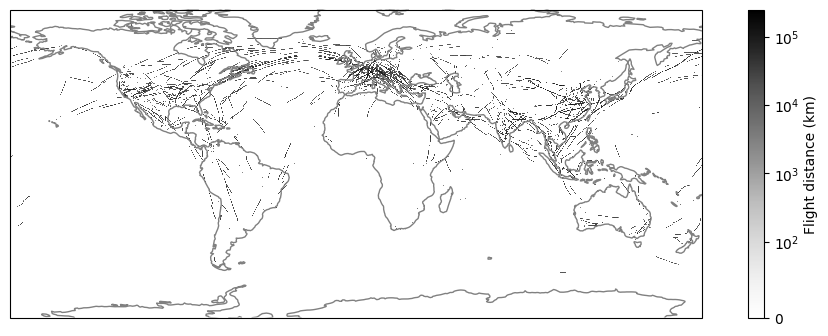

In [47]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
im = ax.pcolormesh(
    ds["longitude"],
    ds["latitude"],
    ds["flight_distance"].T,
    shading="nearest",
    cmap="Greys",
    norm=colors.SymLogNorm(linthresh=100, vmin=0),
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, label="Flight distance (km)")
ax.coastlines(color="gray");

## Use in ContrailBench metrics

The ADS-B evaluation dataset is used in PCR benchmarks to calculate the fraction of global flight distance through forecast contrail regions, a proxy for the cost of contrail avoidance.

This notebook uses the Contrails.org forecast for an example calculation. See the [Contrails.org example notebook](contrails-org.ipynb) for details about accessing and preprocessing the Contrails.org forecast.

In [50]:
url = "https://api.contrails.org/v1/grids"
params = {
    "aircraft_class": "default",
    "flight_level": str(flight_level),
    "time": time.strftime("%Y-%m-%dT%H"),
    "units": "ef_per_m",
}
headers = {"x-api-key": os.environ["CONTRAILS_API_KEY"]}

async with (
    aiohttp.ClientSession(raise_for_status=True) as session,
    session.get(url, params=params, headers=headers) as resp,
):
    content = await resp.read()

with open("forecast.nc", "wb") as f:
    f.write(content)
ds = xr.open_dataset("forecast.nc")

ds["pcr"] = ds["ef_per_m"] != 0
processed = ds[["pcr"]]

The fraction of flight distance inside forecast PCRs can be calculated using some xarray indexing tricks.

In [58]:
target_lon = xr.DataArray(df["longitude"], dims="row")
target_lat = xr.DataArray(df["latitude"], dims="row")
flight_dist = xr.DataArray(df["flight_distance"], dims="row")

pcr = processed["pcr"].sel(longitude=target_lon, latitude=target_lat)
pcr_dist = flight_dist.where(pcr).sum().item()
tot_dist = flight_dist.sum().item()

print(f"Fraction of flight distance inside forecast PCRs: {pcr_dist / tot_dist:.3f}")

Fraction of flight distance inside forecast PCRs: 0.071
